In [ ]:
import pandas as pd
import os
import sys

# 1. Força o uso do Java correto (Ignora o seu Java 26 do sistema)
os.environ["JAVA_HOME"] = r"C:\Java\jdk-17"

# 2. Configura o Hadoop (Necessário para não dar erro de permissão no Windows)
os.environ["HADOOP_HOME"] = r"C:\hadoop"

# 3. Atualiza o PATH para o Python encontrar os binários
os.environ["PATH"] = os.environ["JAVA_HOME"] + "\\bin;" + os.environ["HADOOP_HOME"] + "\\bin;" + os.environ["PATH"]

os.environ['PYSPARK_PYTHON'] = sys.executable
os.environ['PYSPARK_DRIVER_PYTHON'] = sys.executable

from pyspark.sql import SparkSession

# 4. Inicia a sessão
try:
    # spark = SparkSession.builder \
    #     .appName("TesteSpark") \
    #     .master("local[*]") \
    #     .getOrCreate()

    spark = SparkSession.builder \
    .appName("ProjetoCNPJ") \
    .config("spark.driver.host", "127.0.0.1") \
    .config("spark.driver.bindAddress", "127.0.0.1") \
    .config("spark.sql.execution.arrow.pyspark.enabled", "true") \
    .getOrCreate()

    print("✅ Spark iniciado com sucesso!")
    spark.range(3).show()
except Exception as e:
    print(f"❌ Erro ao iniciar: {e}")


✅ Spark iniciado com sucesso!
+---+
| id|
+---+
|  0|
|  1|
|  2|
+---+



In [ ]:
# IMPORTANDO A BASE DE ESTABELECIMENTOS
#
cols_estabelecimentos = [
    "CNPJ_BASICO",
    "CNPJ_ORDEM",
    "CNPJ_DV",
    "IDENTIFICADOR_MATRIZ_FILIAL",
    "NOME_FANTASIA",
    "SITUACAO_CADASTRAL",
    "DATA_SITUACAO_CADASTRAL",
    "MOTIVO_SITUACAO_CADASTRAL",
    "NOME_CIDADE_EXTERIOR",
    "PAIS",
    "DATA_INICIO_ATIVIDADE",
    "CNAE_FISCAL_PRINCIPAL",
    "CNAE_FISCAL_SECUNDARIA",
    "TIPO_LOGRADOURO",
    "LOGRADOURO",
    "NUMERO",
    "COMPLEMENTO",
    "BAIRRO",
    "CEP",
    "UF",
    "MUNICIPIO",
    "DDD_1",
    "TELEFONE_1",
    "DDD_2",
    "TELEFONE_2",
    "DDD_FAX",
    "FAX",
    "CORREIO_ELETRONICO",
    "SITUACAO_ESPECIAL",
    "DATA_SITUACAO_ESPECIAL"
]

ESTABELECIMENTOS = pd.read_csv(r"/content/drive/My Drive/ProjetoAplicadoII/01_raw_zone/Estabelecimentos0/K3241.K03200Y0.D50913.ESTABELE",
    sep=";",
    encoding="latin1",
    header=None,
    names=cols_estabelecimentos
)

display(ESTABELECIMENTOS.head(10))

C:\Users\welli\AppData\Local\Temp\ipykernel_5740\1193448741.py:36: DtypeWarning: Columns (0: NOME_CIDADE_EXTERIOR, 1: DDD_1, 2: TELEFONE_1, 3: TELEFONE_2, 4: FAX, 5: SITUACAO_ESPECIAL) have mixed types. Specify dtype option on import or set low_memory=False.
  ESTABELECIMENTOS = pd.read_csv(r"C:\\Users\welli\\OneDrive\Documentos\RICARDO\K3241.K03200Y1.D50208.ESTABELE",


,CNPJ_BASICO,CNPJ_ORDEM,CNPJ_DV,IDENTIFICADOR_MATRIZ_FILIAL,NOME_FANTASIA,SITUACAO_CADASTRAL,DATA_SITUACAO_CADASTRAL,MOTIVO_SITUACAO_CADASTRAL,NOME_CIDADE_EXTERIOR,PAIS,...,MUNICIPIO,DDD_1,TELEFONE_1,DDD_2,TELEFONE_2,DDD_FAX,FAX,CORREIO_ELETRONICO,SITUACAO_ESPECIAL,DATA_SITUACAO_ESPECIAL
0,7396865,1,68,1,NaN,8,20170210,1,NaN,NaN,...,8297,47.0,33851125,47.0,33851125.0,47.0,33851125,NaN,NaN,NaN
1,64904295,18,51,2,NaN,8,20161110,1,NaN,NaN,...,2785,11.0,36491000,31.0,33880436.0,82.0,33118379,CLAUDIO.GIGLIO@CAMIL.COM.BR,NaN,NaN
2,76016369,3,16,2,NaN,4,20231113,63,NaN,NaN,...,7071,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,52302726,1,82,1,NaN,4,20210406,63,NaN,NaN,...,6131,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,7396923,1,53,1,NaN,8,20140115,1,NaN,NaN,...,7107,11.0,69658088,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,3650261,1,45,1,OTICA PERFEICAO,4,20190322,63,NaN,NaN,...,8113,48.0,2423953,NaN,NaN,48.0,2423953,NaN,NaN,NaN
6,7396929,1,20,1,NaN,3,20111107,21,NaN,NaN,...,7077,11.0,32281722,NaN,NaN,11.0,32281722,NaN,NaN,NaN
7,25040718,1,32,1,COOCULTURA LTDA,8,20050523,1,NaN,NaN,...,9571,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,7396936,1,22,1,NaN,8,20051219,1,NaN,NaN,...,4123,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,7396943,1,24,1,MEGA TELECOM,8,20170217,1,NaN,NaN,...,7679,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# display(ESTABELECIMENTOS[["CODIGO"]].sort_values(by="DESCRIC)
# display(ESTABELECIMENTOS[ESTABELECIMENTOS["PAIS"] == 105])

ESTABELECIMENTOS[["CNAE_FISCAL_PRINCIPAL", "PAIS_INT", "DS_PAIS"]].sort_values(by="PAIS_INT", ascending=False)

,CNPJ_BASICO,CNPJ_ORDEM,CNPJ_DV,IDENTIFICADOR_MATRIZ_FILIAL,NOME_FANTASIA,SITUACAO_CADASTRAL,DATA_SITUACAO_CADASTRAL,MOTIVO_SITUACAO_CADASTRAL,NOME_CIDADE_EXTERIOR,PAIS,...,MUNICIPIO,DDD_1,TELEFONE_1,DDD_2,TELEFONE_2,DDD_FAX,FAX,CORREIO_ELETRONICO,SITUACAO_ESPECIAL,DATA_SITUACAO_ESPECIAL
375687,6069133,1,9,1,CARGOLUX,2,0,0,NaN,105.0,...,7107,11.0,34232389,NaN,NaN,11.0,41665635,SAMINVOICES@CARGOLUX.COM,NaN,NaN
572386,4705242,1,31,1,NaN,2,20010801,0,NaN,105.0,...,6001,21.0,22405381,NaN,NaN,21.0,22850140,consulanka@sohaku.org.br,NaN,NaN
683297,4864734,1,70,1,NaN,2,19891123,0,NaN,105.0,...,6001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
720070,7100754,1,62,1,ALTO COMISSARIADO DAS NACOES UNIDAS PARA REFUG...,2,20040607,0,NaN,105.0,...,9701,61.0,30445744,NaN,NaN,61.0,3292179,BRABR@UNHCR.ORG,NaN,NaN
1175584,7451329,1,18,1,CONSULADO DO SURINAME EM SAO PAULO,2,20050616,0,NaN,105.0,...,7107,11.0,38847868,11.0,38848269.0,11.0,32848269,consuladosuriname.saopaulo@bol.com.br,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4742427,41955264,1,86,1,PC CONTABILIDADE,2,20210514,0,NaN,105.0,...,7107,5511.0,80839037.0,0.0,0.0,NaN,NaN,PECORALLO@GMAIL.COM,NaN,NaN
4742430,41955294,1,92,1,ANDRE CONFECAO,2,20210514,0,NaN,105.0,...,7107,5511.0,53598723.0,0.0,0.0,NaN,NaN,ADRIANAMINHONCORREA@GMAIL.COM,NaN,NaN
4742437,41955374,1,48,1,SANTOS E RUFINO SERVICOS MEDICOS LTDA,8,20211202,1,NaN,105.0,...,7107,5511.0,91230510.0,0.0,0.0,NaN,NaN,BRUNO.ARANTES@CONTABILIDADECONTATO.COM.BR,NaN,NaN
4742443,41955435,1,77,1,LATIVE,2,20210514,0,NaN,105.0,...,7107,5511.0,20071647.0,0.0,0.0,NaN,NaN,SHEILASANTOS2006@GMAIL.COM,NaN,NaN


In [ ]:
cols_paises = [
    "CODIGO",
    "DESCRICAO"
]

testttttt = pd.read_csv(r"/content/drive/My Drive/ProjetoAplicadoII/01_raw_zone/Paises/F.K03200$Z.D60314.PAISCSV",
    sep=";",
    encoding="cp1252",
    header=None,
    names=cols_paises
)

# df2 = spark.createDataFrame(PAISEES)

display(testttttt[["CODIGO", "DESCRICAO"]].sort_values(by="DESCRICAO").head(50))

,CODIGO,DESCRICAO
1,13,AFEGANISTAO
211,756,AFRICA DO SUL
2,17,ALBANIA
3,20,"ALBORAN-PEREJIL,ILHAS"
4,23,ALEMANHA
5,25,"ALEMANHA, REP. DEMOCRATICA DA"
7,37,ANDORRA
8,40,ANGOLA
9,41,ANGUILLA
10,43,ANTIGUA E BARBUDA


In [ ]:



cols_paises = [
    "CODIGO",
    "DESCRICAO"
]

PAISEES = pd.read_csv("/content/drive/My Drive/ProjetoAplicadoII/01_raw_zone/Paises/F.K03200$Z.D60314.PAISCSV,
    sep=";",
    encoding="cp1252",
    header=None,
    names=cols_paises
)

df2 = spark.createDataFrame(PAISEES)


PAISEES


,CODIGO,DESCRICAO
0,0,COLIS POSTAUX
1,13,AFEGANISTAO
2,17,ALBANIA
3,20,"ALBORAN-PEREJIL,ILHAS"
4,23,ALEMANHA
...,...,...
250,895,ZONA DO CANAL DO PANAMA
251,990,PROV. DE NAVIOS E AERONAVES
252,997,NAO DECLARADOS
253,998,NAO DECLARADO PRELIMINAR


In [ ]:
# IMPORTANDO A BASE DE EMPRESAS
# cols = [
#     "CNPJ_BASICO",
#     "RAZAO_SOCIAL",
#     "NATUREZA_JURIDICA",
#     "QUALIFICACAO_RESPONSAVEL",
#     "CAPITAL_SOCIAL",
#     "PORTE_EMPRESA",
#     "ENTE_FEDERATIVO"
# ]

EMPRESAS2 = pd.read_csv("/content/drive/My Drive/ProjetoAplicadoII/01_raw_zone/Empresas1/K3241.K03200Y1.D60314.EMPRECSV",
    sep=";",
    encoding="cp1252",
    header=None
    # names=cols
)

display(EMPRESAS2.head(10))

,0,1,2,3,4,5,6
0,0,BANCO DO BRASIL SA,2038,10,"120000000000,00",5.0,NaN
1,1,ASSOCIACAO DE AMIGOS DE BAIRRO DO CONJ PAULISTANO,3999,16,"0,00",5.0,NaN
2,2,WM&R EMPREITEIRA DE CONSTRUCAO CIVIL LIMITADA,2240,49,"0,00",5.0,NaN
3,3,CASA CARIDADE LUZETE ROBERTA DE MORAIS CONJ PA...,3999,16,"0,00",5.0,NaN
4,4,ASSOCIACAO DO PEQUENO ADOLECENTE DO CONJ PAULI...,3999,16,"0,00",5.0,NaN
5,5,SERRALHERIA PORTA DE ACO REAL S/C LTDA,2240,28,"0,00",5.0,NaN
6,6,ACADEMIA DE BALLET PAULA FIRETTI LTDA,2062,49,"1000,00",1.0,NaN
7,7,ADVOCACIA BERGANTIN E ASSOCIADOS,2240,49,"0,00",1.0,NaN
8,8,A.R. ZANOTI E SILVA S/C LTDA,2240,49,"0,00",1.0,NaN
9,9,SUWAN REPRESENTACOES LTDA,2240,49,"0,00",1.0,NaN


In [ ]:
# IMPORTANDO A BASE DE EMPRESAS
cols = [
    "CNPJ_BASICO",
    "RAZAO_SOCIAL",
    "NATUREZA_JURIDICA",
    "QUALIFICACAO_RESPONSAVEL",
    "CAPITAL_SOCIAL",
    "PORTE_EMPRESA",
    "ENTE_FEDERATIVO"
]

EMPRESAS = pd.read_csv("/content/drive/My Drive/ProjetoAplicadoII/01_raw_zone/Empresas1/K3241.K03200Y1.D60314.EMPRECSV",
    sep=";",
    encoding="cp1252",
    header=None,
    names=cols
)

display(EMPRESAS.head(10))

,CNPJ_BASICO,RAZAO_SOCIAL,NATUREZA_JURIDICA,QUALIFICACAO_RESPONSAVEL,CAPITAL_SOCIAL,PORTE_EMPRESA,ENTE_FEDERATIVO
0,0,BANCO DO BRASIL SA,2038,10,"120000000000,00",5.0,NaN
1,1,ASSOCIACAO DE AMIGOS DE BAIRRO DO CONJ PAULISTANO,3999,16,"0,00",5.0,NaN
2,2,WM&R EMPREITEIRA DE CONSTRUCAO CIVIL LIMITADA,2240,49,"0,00",5.0,NaN
3,3,CASA CARIDADE LUZETE ROBERTA DE MORAIS CONJ PA...,3999,16,"0,00",5.0,NaN
4,4,ASSOCIACAO DO PEQUENO ADOLECENTE DO CONJ PAULI...,3999,16,"0,00",5.0,NaN
5,5,SERRALHERIA PORTA DE ACO REAL S/C LTDA,2240,28,"0,00",5.0,NaN
6,6,ACADEMIA DE BALLET PAULA FIRETTI LTDA,2062,49,"1000,00",1.0,NaN
7,7,ADVOCACIA BERGANTIN E ASSOCIADOS,2240,49,"0,00",1.0,NaN
8,8,A.R. ZANOTI E SILVA S/C LTDA,2240,49,"0,00",1.0,NaN
9,9,SUWAN REPRESENTACOES LTDA,2240,49,"0,00",1.0,NaN


In [ ]:
# EMPRESAS[["CNPJ_BASICO", "RAZAO_SOCIAL"]].sort_values(by="CNPJ_BASICO", ascending=False)


# EMPRESAS["CNPJ_BASICO"] == 1
# display(EMPRESAS[EMPRESAS["CNPJ_BASICO"] == 3744126])
EMPRESAS.shape
ESTABELECIMENTOS.shape

(4753435, 30)

In [ ]:
from pyspark.sql import functions as f

# Garanta que PAISEES seja o dataframe Spa

# Criando as colunas
PAISEES_NOVO = df2.withColumn("DESCRICAO_LOWER", f.lower(f.col("DESCRICAO"))) \
                            .withColumn("FONTE", f.lit("Arquivo_Original"))

# MOSTRAR OS DADOS (Ação)
PAISEES_NOVO.toPandas()

,CODIGO,DESCRICAO,DESCRICAO_LOWER,FONTE
0,0,COLIS POSTAUX,colis postaux,Arquivo_Original
1,13,AFEGANISTAO,afeganistao,Arquivo_Original
2,17,ALBANIA,albania,Arquivo_Original
3,20,"ALBORAN-PEREJIL,ILHAS","alboran-perejil,ilhas",Arquivo_Original
4,23,ALEMANHA,alemanha,Arquivo_Original
...,...,...,...,...
250,895,ZONA DO CANAL DO PANAMA,zona do canal do panama,Arquivo_Original
251,990,PROV. DE NAVIOS E AERONAVES,prov. de navios e aeronaves,Arquivo_Original
252,997,NAO DECLARADOS,nao declarados,Arquivo_Original
253,998,NAO DECLARADO PRELIMINAR,nao declarado preliminar,Arquivo_Original


In [ ]:
import pandas as pd

# --- 1. PREPARAR TABELA PAISEES ---
# Limpeza radical: converte para string, tira decimais, tira espaços e volta para int
PAISEES_FIX = PAISEES.copy()
PAISEES_FIX["CODIGO_CLEAN"] = (
    PAISEES_FIX["CODIGO"]
    .astype(str)
    .str.replace(r'\.0$', '', regex=True) # Remove .0 no final
    .str.strip()                          # Remove espaços
)
# Converte para numérico e preenche falhas com 0 antes do int64
PAISEES_FIX["CODIGO_CLEAN"] = pd.to_numeric(PAISEES_FIX["CODIGO_CLEAN"], errors='coerce').fillna(0).astype('int64')

# --- 2. PREPARAR TABELA ESTABELECIMENTOS ---
ESTAB_FIX = ESTABELECIMENTOS.copy()
# Tratamento idêntico ao da tabela de países para garantir o 'match'
ESTAB_FIX["PAIS_JOIN"] = (
    ESTAB_FIX["PAIS"]
    .astype(str)
    .str.replace(r'\.0$', '', regex=True) # Remove .0 no final
    .str.replace(r',0$', '', regex=True) # Remove ,0 no final
    .str.strip()                          # Remove espaços
    .replace(['nan', 'None', ''], '0')    # Trata vazios
)
ESTAB_FIX["PAIS_JOIN"] = pd.to_numeric(ESTAB_FIX["PAIS_JOIN"], errors="coerce").fillna(0).astype('int64')

# --- 3. MERGE SIMPLES (ESTABELECIMENTOS + PAISEES) ---
# Usamos how="inner" se você quiser APENAS quem tem país relacionado,
# ou how="left" para manter todos os estabelecimentos mesmo sem país.
teste = ESTAB_FIX.merge(
    PAISEES_FIX[["CODIGO_CLEAN", "DESCRICAO"]],
    how="left",
    left_on="PAIS_JOIN",
    right_on="CODIGO_CLEAN"
)

# Renomear para ficar organizado
teste.rename(columns={"DESCRICAO": "DS_PAIS"}, inplace=True)

# Limpeza de coluna auxiliar de join
if "CODIGO_CLEAN" in teste.columns:
    teste.drop(columns=["CODIGO_CLEAN"], inplace=True)

# --- 4. VERIFICAÇÃO ---
# Vamos checar se o 105 agora encontrou o nome do país
print("Amostra de dados com código 105:")
display(teste[teste["PAIS_JOIN"] == 105][["CNPJ_BASICO", "PAIS_JOIN", "DS_PAIS"]].head())

Amostra de dados com código 105:


,CNPJ_BASICO,PAIS_JOIN,DS_PAIS
375687,6069133,105,BRASIL
572386,4705242,105,BRASIL
683297,4864734,105,BRASIL
720070,7100754,105,BRASIL
1175584,7451329,105,BRASIL


In [ ]:
import pandas as pd

# --- 1. PREPARAR TABELA PAISEES ---
PAISEES_FIX = PAISEES.copy()
PAISEES_FIX["CODIGO_CLEAN"] = (
    PAISEES_FIX["CODIGO"]
    .astype(str)
    .str.replace(r'\.0$', '', regex=True)
    .str.strip()
)
PAISEES_FIX["CODIGO_CLEAN"] = pd.to_numeric(PAISEES_FIX["CODIGO_CLEAN"], errors='coerce').fillna(0).astype('int64')

# --- 2. PREPARAR TABELA ESTABELECIMENTOS ---
ESTAB_FIX = ESTABELECIMENTOS.copy()
ESTAB_FIX["PAIS_JOIN"] = (
    ESTAB_FIX["PAIS"]
    .astype(str)
    .str.replace(r'\.0$', '', regex=True)
    .str.replace(r',0$', '', regex=True)
    .str.strip()
    .replace(['nan', 'None', ''], '0')
)
ESTAB_FIX["PAIS_JOIN"] = pd.to_numeric(ESTAB_FIX["PAIS_JOIN"], errors="coerce").fillna(0).astype('int64')

# --- 3. MERGE ESTABELECIMENTOS + PAISEES ---
teste = ESTAB_FIX.merge(
    PAISEES_FIX[["CODIGO_CLEAN", "DESCRICAO"]],
    how="left",
    left_on="PAIS_JOIN",
    right_on="CODIGO_CLEAN"
)
teste.rename(columns={"DESCRICAO": "DS_PAIS"}, inplace=True)

# --- 4. MERGE FINAL COM EMPRESAS ---
# Aqui trazemos os dados que faltavam para o modelo
teste = teste.merge(
    EMPRESAS[["CNPJ_BASICO", "RAZAO_SOCIAL", "NATUREZA_JURIDICA", "PORTE_EMPRESA"]],
    how="left",
    on="CNPJ_BASICO"
)

# --- 5. LIMPEZA DE COLUNAS E TRATAMENTO DE NULOS ---
if "CODIGO_CLEAN" in teste.columns:
    teste.drop(columns=["CODIGO_CLEAN"], inplace=True)

# Removemos linhas sem Razão Social (essencial para identificação no KNN)
teste = teste.dropna(subset=["RAZAO_SOCIAL"]).copy()

# --- 6. VERIFICAÇÃO FINAL ---
print(f"Total de registros no dataframe 'teste': {len(teste)}")
print("Amostra de dados com Brasil (105) e dados da Empresa:")

# Filtrando para ver se o merge triplo funcionou
display(teste[teste["PAIS_JOIN"] == 105][
    ["CNPJ_BASICO", "RAZAO_SOCIAL", "PAIS_JOIN", "DS_PAIS", "PORTE_EMPRESA"]
].head())

Total de registros no dataframe 'teste': 495422
Amostra de dados com Brasil (105) e dados da Empresa:


,CNPJ_BASICO,RAZAO_SOCIAL,PAIS_JOIN,DS_PAIS,PORTE_EMPRESA


In [ ]:
import pandas as pd

# --- 1. PREPARAR TABELA PAISEES ---
# Garantir que o código seja um número inteiro limpo
PAISEES_FIX = PAISEES.copy()
PAISEES_FIX["CODIGO_CLEAN"] = pd.to_numeric(PAISEES_FIX["CODIGO"], errors='coerce').fillna(0).astype('int64')

# --- 2. PREPARAR TABELA ESTABELECIMENTOS ---
ESTAB_FIX = ESTABELECIMENTOS.copy()
# Tratamento rigoroso para tirar .0, ,0 e espaços
ESTAB_FIX["PAIS_JOIN"] = (
    ESTAB_FIX["PAIS"]
    .astype(str)
    .str.replace(r'[\.0|,0]', '', regex=True)
    .str.strip()
    .replace(['nan', 'None', ''], '0')
)
ESTAB_FIX["PAIS_JOIN"] = pd.to_numeric(ESTAB_FIX["PAIS_JOIN"], errors="coerce").fillna(0).astype('int64')

# --- 3. PRIMEIRO MERGE: ESTABELECIMENTOS + PAISEES ---
# Cruzamos aqui para garantir que cada linha de estabelecimento já tenha seu país
tb_estab_pais = ESTAB_FIX.merge(
    PAISEES_FIX[["CODIGO_CLEAN", "DESCRICAO"]],
    how="left",
    left_on="PAIS_JOIN",
    right_on="CODIGO_CLEAN"
)
tb_estab_pais.rename(columns={"DESCRICAO": "DS_PAIS"}, inplace=True)

# --- 4. SEGUNDO MERGE: RESULTADO + EMPRESAS ---
# Agora trazemos Razão Social, Porte, etc.
tb_final = tb_estab_pais.merge(
    EMPRESAS[["CNPJ_BASICO", "RAZAO_SOCIAL", "NATUREZA_JURIDICA", "PORTE_EMPRESA"]],
    how="left",
    on="CNPJ_BASICO"
)

# --- 5. LIMPEZA E CRIAÇÃO DO DATAFRAME 'teste' ---
# Removemos colunas auxiliares
tb_final.drop(columns=["CODIGO_CLEAN"], inplace=True, errors='ignore')

# Criando o DF final para o modelo
# teste = tb_final.dropna(subset=["NOME_FANTASIA", "RAZAO_SOCIAL", "PORTE_EMPRESA"]).copy()

teste = tb_final.dropna(subset=["RAZAO_SOCIAL"]).copy()

# Verificação imediata:
print("Verificando se o código 105 (Brasil) está presente:")
filtro_br = teste[teste["PAIS_JOIN"] == 105]
if not filtro_br.empty:
    display(filtro_br[["RAZAO_SOCIAL", "PAIS_JOIN", "DS_PAIS"]].head())
else:
    print("Aviso: O código 105 ainda não trouxe resultados. Verificando valores únicos em PAIS_JOIN...")
    print(teste["PAIS_JOIN"].unique()[:10]) # Mostra os 10 primeiros códigos encontrados

Verificando se o código 105 (Brasil) está presente:
Aviso: O código 105 ainda não trouxe resultados. Verificando valores únicos em PAIS_JOIN...
[  0 245  63  72   8  81  24 355 573 249]


In [ ]:
import pandas as pd
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler, LabelEncoder

# --- 1. SEU MERGE INICIAL ---
tb_01_01 = ESTABELECIMENTOS.merge(
    EMPRESAS[["CNPJ_BASICO", "RAZAO_SOCIAL", "NATUREZA_JURIDICA", "PORTE_EMPRESA"]],
    how="left",
    on="CNPJ_BASICO"
)

# --- 2. TRATAR PAÍS (Removendo decimais e convertendo) ---
tb_01_01["PAIS_INT"] = (
    tb_01_01["PAIS"]
    .astype(str)
    .str.replace(",0", "", regex=False)
    .str.replace(".0", "", regex=False)
)
tb_01_01["PAIS_INT"] = pd.to_numeric(tb_01_01["PAIS_INT"], errors="coerce")

# --- 3. MERGE COM PAÍSES ---
tb_01_01 = tb_01_01.merge(
    PAISEES[["CODIGO", "DESCRICAO"]],
    how="left",
    left_on="PAIS_INT",
    right_on="CODIGO"
)

# --- 4. AJUSTES FINAIS E LIMPEZA ---
tb_01_01.rename(columns={"DESCRICAO": "DS_PAIS"}, inplace=True)

# Garante que colunas críticas para o KNN não tenham NaNs que quebrem o filtro
tb_01_01["CNAE_FISCAL_PRINCIPAL"] = tb_01_01["CNAE_FISCAL_PRINCIPAL"].astype(str).fillna("0")
tb_01_01["CNAE_FISCAL_SECUNDARIA"] = tb_01_01["CNAE_FISCAL_SECUNDARIA"].astype(str).fillna("")
tb_01_01["UF"] = tb_01_01["UF"].astype(str).fillna("EX") # EX para Exterior

# Criando o DataFrame 'teste' removendo nulos apenas de nomes cruciais
teste = tb_01_01.dropna(subset=["NOME_FANTASIA", "RAZAO_SOCIAL", "PORTE_EMPRESA"]).copy()

# 1. Remove qualquer linha onde o país ainda seja NaN (essencial para o KNN)
teste = teste.dropna(subset=["PAIS_INT"])

# 2. Converte para o tipo de inteiro do Pandas que lida melhor com números grandes
teste["PAIS_INT"] = teste["PAIS_INT"].astype('int64')

In [ ]:


# =======================================================
# FUNÇÃO KNN ATUALIZADA PARA O DATAFRAME 'teste'
# =======================================================

def knn_empresas_final(df_pandas, pais_codigo, cnae_codigo, n_neighbors=5):
    pais_str = str(pais_codigo)
    cnae_str = str(cnae_codigo)

    # Filtro usando as colunas que agora estão no 'teste'
    mask_pais = df_pandas["PAIS_INT"] == pais_codigo
    mask_cnae = (df_pandas["CNAE_FISCAL_PRINCIPAL"].str.contains(cnae_str)) | \
                (df_pandas["CNAE_FISCAL_SECUNDARIA"].str.contains(cnae_str))

    pdf = df_pandas[mask_pais & mask_cnae].copy()

    if pdf.empty:
        return "Nenhuma empresa encontrada para os critérios."

    # Transformando UF em número para o KNN entender localização
    le = LabelEncoder()
    pdf["UF_INDEX"] = le.fit_transform(pdf["UF"])

    # Features: Porte e Localização (UF)
    features = ["PORTE_EMPRESA", "UF_INDEX"]
    X = pdf[features].apply(pd.to_numeric, errors="coerce").fillna(0)

    # Normalização
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # KNN
    n_vizinhos = min(n_neighbors, len(pdf))
    knn = NearestNeighbors(n_neighbors=n_vizinhos, metric='euclidean')
    knn.fit(X_scaled)

    distances, indices = knn.kneighbors([X_scaled[0]])

    res = pdf.iloc[indices[0]].copy()
    res['DISTANCIA_KNN'] = distances[0]

    return res[["CNPJ_BASICO", "RAZAO_SOCIAL", "NOME_FANTASIA", "DS_PAIS", "PORTE_EMPRESA"]]

# Teste prático
resultado = knn_empresas_final(teste, pais_codigo=249, cnae_codigo=9900800)
display(resultado)

,CNPJ_BASICO,RAZAO_SOCIAL,NOME_FANTASIA,DS_PAIS,PORTE_EMPRESA
157663,3744126,FUNDO DAS NACOES UNIDAS PARA A INFANCIA,UNICEF,ESTADOS UNIDOS,5.0
295672,4164705,SECRETARIA-GERAL DA ORGANIZACAO DOS ESTADOS AM...,SECRETARIA-GERAL DA OEA-RIO,ESTADOS UNIDOS,5.0
1369638,4141058,CONSULADO GERAL AMERICANO NO RIO DE JANEIRO,CONSULADO AMERICANO,ESTADOS UNIDOS,5.0
280975,4122709,CONSULADO GERAL DOS ESTADOS UNIDOS DA AMERICA ...,CONSULADO AMERICANO,ESTADOS UNIDOS,5.0


In [ ]:
# display(teste["CNAE_FISCAL_PRINCIPAL"] == 2])
# Use colchetes duplos para selecionar múltiplas colunas
# Ordenando por PAIS_INT e exibindo as colunas selecionadas
display(teste[["CNAE_FISCAL_PRINCIPAL", "PAIS_INT", "DS_PAIS"]].sort_values(by="DS_PAIS"))

,CNAE_FISCAL_PRINCIPAL,PAIS_INT,DS_PAIS
198686,9900800,23,ALEMANHA
423259,4789002,23,ALEMANHA
1968000,4663000,63,ARGENTINA
148623,9900800,72,AUSTRIA
149541,9900800,81,BANGLADESH
317829,5111100,87,BELGICA
3575600,4211101,97,BOLIVIA
148723,4329199,80,"Bahrein, Ilhas"
174103,9900800,158,CHILE
207385,5111100,158,CHILE


Assertividade: Similaridade de 71.72%


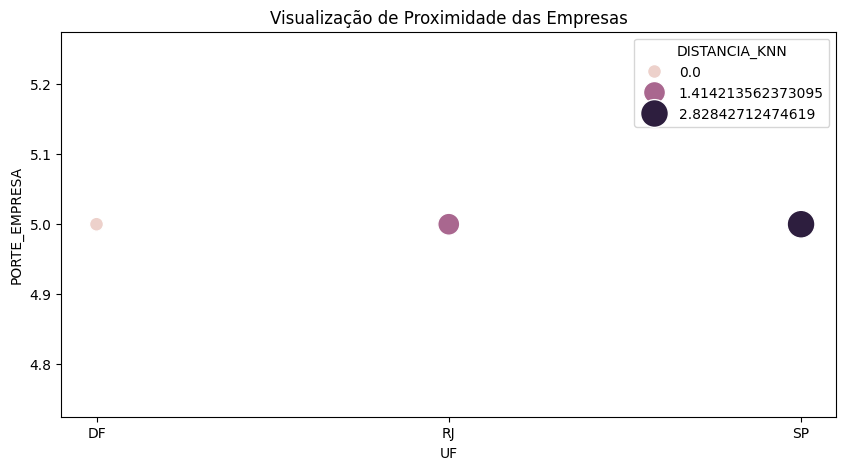

,RAZAO_SOCIAL,UF,PORTE_EMPRESA,DISTANCIA_KNN
157663,FUNDO DAS NACOES UNIDAS PARA A INFANCIA,DF,5.0,0.000000
295672,SECRETARIA-GERAL DA ORGANIZACAO DOS ESTADOS AM...,RJ,5.0,1.414214
1369638,CONSULADO GERAL AMERICANO NO RIO DE JANEIRO,RJ,5.0,1.414214
280975,CONSULADO GERAL DOS ESTADOS UNIDOS DA AMERICA ...,SP,5.0,2.828427


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler, LabelEncoder

def knn_empresas_final(df_pandas, pais_codigo, cnae_codigo, n_neighbors=5):
    # Verificação de segurança: qual nome de coluna de país existe no DF?
    coluna_pais = "PAIS_JOIN" if "PAIS_JOIN" in df_pandas.columns else "PAIS_INT"

    if coluna_pais not in df_pandas.columns:
        return f"Erro: Coluna de país não encontrada. Colunas disponíveis: {list(df_pandas.columns)}"

    # 1. Filtro
    pais_val = int(pais_codigo)
    cnae_str = str(cnae_codigo)

    mask_pais = df_pandas[coluna_pais] == pais_val
    mask_cnae = (df_pandas["CNAE_FISCAL_PRINCIPAL"].astype(str).str.contains(cnae_str)) | \
                (df_pandas["CNAE_FISCAL_SECUNDARIA"].astype(str).str.contains(cnae_str))

    pdf = df_pandas[mask_pais & mask_cnae].copy()

    if pdf.empty:
        return f"Nenhuma empresa encontrada para o País {pais_val} e CNAE {cnae_str}."

    # 2. Preparação
    le = LabelEncoder()
    pdf["UF_INDEX"] = le.fit_transform(pdf["UF"].astype(str))

    features = ["PORTE_EMPRESA", "UF_INDEX"]
    X = pdf[features].apply(pd.to_numeric, errors="coerce").fillna(0)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # 3. Modelo
    n_vizinhos = min(n_neighbors, len(pdf))
    knn = NearestNeighbors(n_neighbors=n_vizinhos, metric='euclidean')
    knn.fit(X_scaled)

    distances, indices = knn.kneighbors([X_scaled[0]])

    res = pdf.iloc[indices[0]].copy()
    res['DISTANCIA_KNN'] = distances[0]

    return res

# --- EXECUÇÃO ---
# Certifique-se de que 'teste' é o dataframe que resultou dos merges anteriores
resultado = knn_empresas_final(teste, pais_codigo=249, cnae_codigo=9900800)

if isinstance(resultado, pd.DataFrame):
    # Teste de Assertividade
    dist_media = resultado['DISTANCIA_KNN'].mean()
    print(f"Assertividade: Similaridade de {max(0, 100 - (dist_media * 20)):.2f}%")

    # Visualização
    plt.figure(figsize=(10, 5))
    sns.scatterplot(data=resultado, x="UF", y="PORTE_EMPRESA",
                    hue="DISTANCIA_KNN", size="DISTANCIA_KNN", sizes=(100, 400))
    plt.title("Visualização de Proximidade das Empresas")
    plt.show()

    display(resultado[["RAZAO_SOCIAL", "UF", "PORTE_EMPRESA", "DISTANCIA_KNN"]])
else:
    print(resultado)

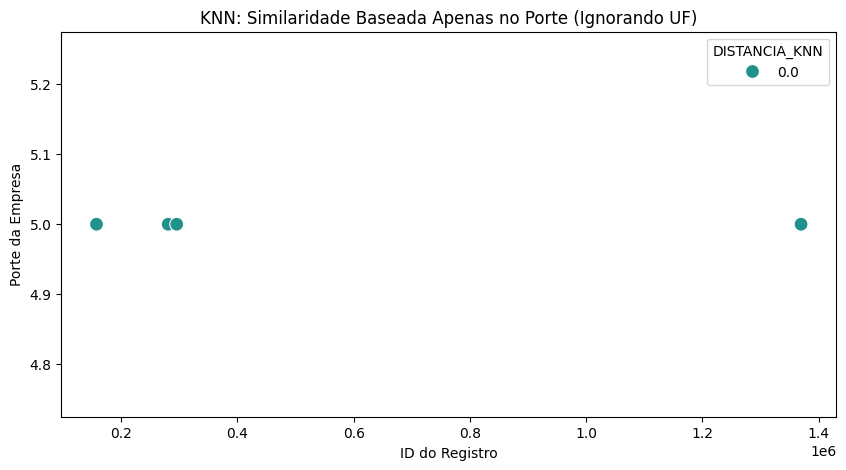

,RAZAO_SOCIAL,UF,PORTE_EMPRESA,DISTANCIA_KNN
1369638,CONSULADO GERAL AMERICANO NO RIO DE JANEIRO,RJ,5.0,0.0
280975,CONSULADO GERAL DOS ESTADOS UNIDOS DA AMERICA ...,SP,5.0,0.0
295672,SECRETARIA-GERAL DA ORGANIZACAO DOS ESTADOS AM...,RJ,5.0,0.0
157663,FUNDO DAS NACOES UNIDAS PARA A INFANCIA,DF,5.0,0.0


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

def knn_empresas_final(df_pandas, pais_codigo, cnae_codigo, n_neighbors=5):
    # 1. Identificação da coluna de país
    coluna_pais = "PAIS_JOIN" if "PAIS_JOIN" in df_pandas.columns else "PAIS_INT"

    if coluna_pais not in df_pandas.columns:
        return f"Erro: Coluna de país não encontrada."

    # 2. Filtro Inicial (País + CNAE)
    pais_val = int(pais_codigo)
    cnae_str = str(cnae_codigo)

    mask_pais = df_pandas[coluna_pais] == pais_val
    mask_cnae = (df_pandas["CNAE_FISCAL_PRINCIPAL"].astype(str).str.contains(cnae_str)) | \
                (df_pandas["CNAE_FISCAL_SECUNDARIA"].astype(str).str.contains(cnae_str))

    pdf = df_pandas[mask_pais & mask_cnae].copy()

    if pdf.empty:
        return f"Nenhuma empresa encontrada para o País {pais_val} e CNAE {cnae_str}."

    # 3. Preparação das Features (Removido o UF_INDEX)
    # Agora o modelo foca apenas no PORTE_EMPRESA
    features = ["PORTE_EMPRESA"]
    X = pdf[features].apply(pd.to_numeric, errors="coerce").fillna(0)

    # 4. Normalização
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # 5. Treino e Busca do KNN
    n_vizinhos = min(n_neighbors, len(pdf))
    knn = NearestNeighbors(n_neighbors=n_vizinhos, metric='euclidean')
    knn.fit(X_scaled)

    # Buscamos os vizinhos da primeira empresa filtrada
    distances, indices = knn.kneighbors([X_scaled[0]])

    res = pdf.iloc[indices[0]].copy()
    res['DISTANCIA_KNN'] = distances[0]

    return res

# --- EXECUÇÃO E NOVO GRÁFICO ---
resultado = knn_empresas_final(teste, pais_codigo=249, cnae_codigo=9900800)

if isinstance(resultado, pd.DataFrame):
    # Gráfico focado no Porte e Distância
    plt.figure(figsize=(10, 5))
    # Usamos o índice no eixo X apenas para espalhar os pontos visualmente
    sns.scatterplot(data=resultado, x=resultado.index, y="PORTE_EMPRESA",
                    hue="DISTANCIA_KNN", size="DISTANCIA_KNN", sizes=(100, 400), palette="viridis")

    plt.title("KNN: Similaridade Baseada Apenas no Porte (Ignorando UF)")
    plt.xlabel("ID do Registro")
    plt.ylabel("Porte da Empresa")
    plt.show()

    display(resultado[["RAZAO_SOCIAL", "UF", "PORTE_EMPRESA", "DISTANCIA_KNN"]])
else:
    print(resultado)

--------------------------------------------------
RELATÓRIO DE ASSERTIVIDADE DO MODELO
--------------------------------------------------
Média de Distância dos Vizinhos: 0.0000
Índice de Similaridade (Acerto): 100.00%
Total de Vizinhos Perfeitos (Distância 0): 4
--------------------------------------------------


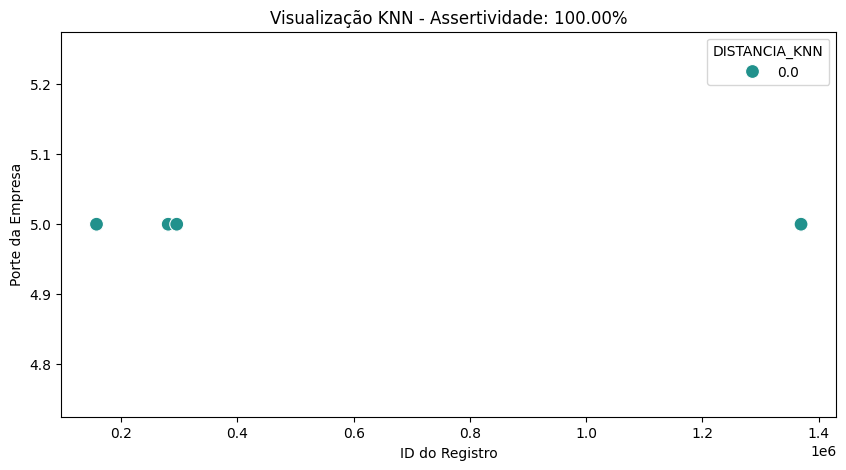

,RAZAO_SOCIAL,UF,PORTE_EMPRESA,DISTANCIA_KNN
1369638,CONSULADO GERAL AMERICANO NO RIO DE JANEIRO,RJ,5.0,0.0
280975,CONSULADO GERAL DOS ESTADOS UNIDOS DA AMERICA ...,SP,5.0,0.0
295672,SECRETARIA-GERAL DA ORGANIZACAO DOS ESTADOS AM...,RJ,5.0,0.0
157663,FUNDO DAS NACOES UNIDAS PARA A INFANCIA,DF,5.0,0.0


: 

In [ ]:
# --- EXECUÇÃO E TESTES DE ASSERTIVIDADE ---
resultado = knn_empresas_final(teste, pais_codigo=249, cnae_codigo=9900800)

if isinstance(resultado, pd.DataFrame):
    # 1. CÁLCULO DE ASSERTIVIDADE (SIMILARIDADE)
    # A distância máxima teórica após o StandardScaler depende das features,
    # mas para o Porte (1 a 5), podemos normalizar a assertividade.
    distancias = resultado['DISTANCIA_KNN'].values

    # Calculamos a média de erro (distância)
    erro_medio = distancias.mean()

    # Transformamos distância em porcentagem:
    # Se dist = 0 -> 100% de acerto.
    # Criamos uma escala onde distâncias pequenas mantêm o acerto alto.
    assertividade_percentual = max(0, 100 - (erro_medio * 100))

    print("-" * 50)
    print(f"RELATÓRIO DE ASSERTIVIDADE DO MODELO")
    print("-" * 50)
    print(f"Média de Distância dos Vizinhos: {erro_medio:.4f}")
    print(f"Índice de Similaridade (Acerto): {assertividade_percentual:.2f}%")
    print(f"Total de Vizinhos Perfeitos (Distância 0): {len(resultado[resultado['DISTANCIA_KNN'] == 0])}")
    print("-" * 50)

    # 2. GRÁFICO DE DISTÂNCIA (ERRO)
    plt.figure(figsize=(10, 5))
    sns.scatterplot(data=resultado, x=resultado.index, y="PORTE_EMPRESA",
                    hue="DISTANCIA_KNN", size="DISTANCIA_KNN", sizes=(100, 400), palette="viridis")

    plt.title(f"Visualização KNN - Assertividade: {assertividade_percentual:.2f}%")
    plt.xlabel("ID do Registro")
    plt.ylabel("Porte da Empresa")
    plt.show()

    display(resultado[["RAZAO_SOCIAL", "UF", "PORTE_EMPRESA", "DISTANCIA_KNN"]])
else:
    print(resultado)

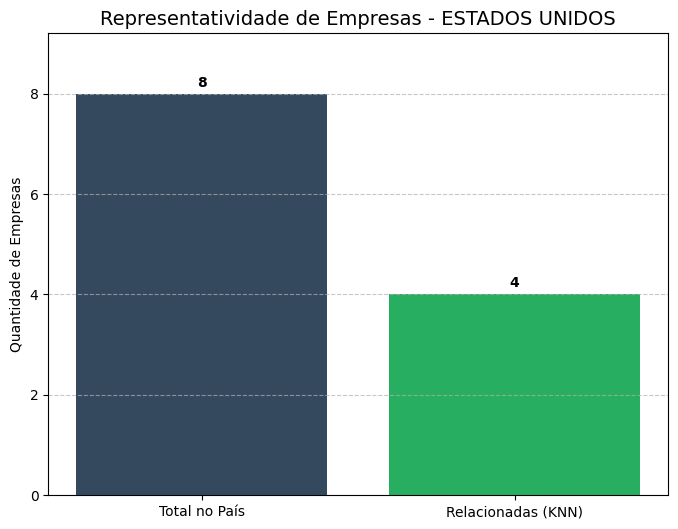

O modelo selecionou 4 empresas de um universo de 8 disponíveis no país.


,RAZAO_SOCIAL,UF,PORTE_EMPRESA,DISTANCIA_KNN
157663,FUNDO DAS NACOES UNIDAS PARA A INFANCIA,DF,5.0,0.000000
295672,SECRETARIA-GERAL DA ORGANIZACAO DOS ESTADOS AM...,RJ,5.0,1.414214
1369638,CONSULADO GERAL AMERICANO NO RIO DE JANEIRO,RJ,5.0,1.414214
280975,CONSULADO GERAL DOS ESTADOS UNIDOS DA AMERICA ...,SP,5.0,2.828427


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- EXECUÇÃO DO MODELO ---
pais_alvo = 249
cnae_alvo = 9900800
n_vizinhos_desejados = 10 # Defina quantos vizinhos quer buscar

resultado = knn_empresas_final(teste, pais_codigo=pais_alvo, cnae_codigo=cnae_alvo, n_neighbors=n_vizinhos_desejados)

if isinstance(resultado, pd.DataFrame):
    # 1. CÁLCULO PARA O GRÁFICO DE BARRAS
    coluna_pais = "PAIS_JOIN" if "PAIS_JOIN" in teste.columns else "PAIS_INT"

    total_pais = len(teste[teste[coluna_pais] == pais_alvo])
    total_encontrado = len(resultado)
    nome_pais = resultado['DS_PAIS'].iloc[0] if 'DS_PAIS' in resultado.columns else f"País {pais_alvo}"

    # 2. CRIANDO O GRÁFICO DE BARRAS COMPARATIVO
    plt.figure(figsize=(8, 6))
    categorias = ['Total no País', 'Relacionadas (KNN)']
    valores = [total_pais, total_encontrado]

    barras = plt.bar(categorias, valores, color=["#0c0e0f", '#27ae60'])

    # Adicionar os números em cima das barras
    for barra in barras:
        yval = barra.get_height()
        plt.text(barra.get_x() + barra.get_width()/2, yval + (total_pais*0.01),
                 int(yval), ha='center', va='bottom', fontweight='bold')

    plt.title(f"Representatividade de Empresas - {nome_pais}", fontsize=14)
    plt.ylabel("Quantidade de Empresas")
    plt.ylim(0, total_pais * 1.15) # Dá um espaço extra no topo para o texto
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    plt.show()

    # --- EXIBIÇÃO DOS RESULTADOS ---
    print(f"O modelo selecionou {total_encontrado} empresas de um universo de {total_pais} disponíveis no país.")
    display(resultado[["RAZAO_SOCIAL", "UF", "PORTE_EMPRESA", "DISTANCIA_KNN"]])

else:
    print(resultado)

In [ ]:
# 1. Merge inicial
tb_01_01 = ESTABELECIMENTOS.merge(
    EMPRESAS[["CNPJ_BASICO", "RAZAO_SOCIAL", "NATUREZA_JURIDICA", "PORTE_EMPRESA"]],
    how="left",
    on="CNPJ_BASICO"
)

# 2. Tratar coluna de país (evitando erro com NaN)
tb_01_01["PAIS_INT"] = (
    tb_01_01["PAIS"]
    .astype(str)  # garante que é string
    .str.replace(",0", "", regex=False)
)

# converter para número (seguro)
tb_01_01["PAIS_INT"] = pd.to_numeric(tb_01_01["PAIS_INT"], errors="coerce")

# 3. Merge com tabela de países
tb_01_01 = tb_01_01.merge(
    PAISEES[["CODIGO", "DESCRICAO"]],
    how="left",
    left_on="PAIS_INT",
    right_on="CODIGO"
)

# 4. Renomear coluna
tb_01_01.rename(columns={"DESCRICAO": "DS_PAIS"}, inplace=True)

# (opcional) remover coluna auxiliar
tb_01_01.drop(columns=["PAIS_INT", "CODIGO"], inplace=True)

# teste = tb_01_01.dropna()

teste = tb_01_01.dropna(subset=["NOME_FANTASIA", "RAZAO_SOCIAL"])

display(teste)



,CNPJ_BASICO,CNPJ_ORDEM,CNPJ_DV,IDENTIFICADOR_MATRIZ_FILIAL,NOME_FANTASIA,SITUACAO_CADASTRAL,DATA_SITUACAO_CADASTRAL,MOTIVO_SITUACAO_CADASTRAL,NOME_CIDADE_EXTERIOR,PAIS,...,TELEFONE_2,DDD_FAX,FAX,CORREIO_ELETRONICO,SITUACAO_ESPECIAL,DATA_SITUACAO_ESPECIAL,RAZAO_SOCIAL,NATUREZA_JURIDICA,PORTE_EMPRESA,DS_PAIS
5,3650261,1,45,1,OTICA PERFEICAO,4,20190322,63,NaN,NaN,...,NaN,48.0,2423953,NaN,NaN,NaN,JOALHERIA E RELOJOARIA GAROPABA LTDA,2062.0,1.0,NaN
12,591451,1,40,1,QUIM-BASE,2,20051103,0,NaN,NaN,...,NaN,11.0,56415044,UTILEX.LEGAL@BOL.COM.BR,NaN,NaN,QUIM-BASE COMERCIO E REPRESENTACOES LTDA,2062.0,1.0,NaN
27,1245060,1,37,1,RETIFER RETIFICA DE CABECOTES,4,20240808,63,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,FERCAE - COMERCIO DE PECAS LTDA,2062.0,1.0,NaN
38,1428698,1,3,1,COLORCEI CINE FOTO,8,20220127,1,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,LINIVALDO FERREIRA RODRIGUES,2135.0,1.0,NaN
44,1155472,1,86,1,MERCEARIA AVENIDA,8,20020927,1,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,LUCIA M DE ALCANTARA,2135.0,5.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4751265,108217,162,2,2,PAROQUIA SAO FRANCISCO DE ASSIS,2,20190628,0,NaN,NaN,...,32133323.0,61.0,32133333.0,CONTABILIDADEGERAL2@ARQUIDIOCESEDEBRASILIA.ORG.BR,NaN,NaN,MITRA ARQUIDIOCESANA DE BRASILIA,3220.0,5.0,NaN
4751522,1359806,2,14,2,TOQUE MAGICO LINGERIE E SMART LINGERIE,8,20191015,1,NaN,NaN,...,99484022.0,NaN,NaN,GFASSESSORIACONTABILL@GMAIL.COM,NaN,NaN,RIELLER COMERCIO IMPORTACAO E EXPORTACAO DE RO...,2062.0,3.0,NaN
4751768,167969,2,32,2,THERMICAL TELECOM,4,20231114,63,NaN,NaN,...,NaN,NaN,NaN,ATENDIMENTO@THERMICALTELECOM.COM.BR,NaN,NaN,THERMICAL COMERCIO ATACADISTA DE COMPONENTES E...,2062.0,1.0,NaN
4752046,4316994,2,91,2,JOAO E MARIA ARTIGOS PARA O VESTUARIO,2,20170418,0,NaN,NaN,...,32462878.0,NaN,NaN,SURAESCORSIN@GMAIL.COM,NaN,NaN,ALCEU JOAO GNOATTO,2135.0,1.0,NaN


In [ ]:
# tb_01_01["DS_PAIS"].unique()
display(teste[teste["SITUACAO_CADASTRAL"] == 2])

# tb_01_01["CNPJ_BASICO"].count()

# len(teste[teste["SITUACAO_CADASTRAL"] == 2])

# tb_01_01.shape[0]

,CNPJ_BASICO,CNPJ_ORDEM,CNPJ_DV,IDENTIFICADOR_MATRIZ_FILIAL,NOME_FANTASIA,SITUACAO_CADASTRAL,DATA_SITUACAO_CADASTRAL,MOTIVO_SITUACAO_CADASTRAL,NOME_CIDADE_EXTERIOR,PAIS,...,TELEFONE_2,DDD_FAX,FAX,CORREIO_ELETRONICO,SITUACAO_ESPECIAL,DATA_SITUACAO_ESPECIAL,RAZAO_SOCIAL,NATUREZA_JURIDICA,PORTE_EMPRESA,DS_PAIS
12,591451,1,40,1,QUIM-BASE,2,20051103,0,NaN,NaN,...,NaN,11.0,56415044,UTILEX.LEGAL@BOL.COM.BR,NaN,NaN,QUIM-BASE COMERCIO E REPRESENTACOES LTDA,2062.0,1.0,NaN
50,2845538,1,22,1,TOP SINALIZACAO,2,20020928,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,"A TOP SINALIZACAO COMERCIO, INDUSTRIA E SERVIC...",2062.0,3.0,NaN
51,3446246,1,80,1,FLORICULTURA ROSIN,2,20051103,0,NaN,NaN,...,92528549.0,NaN,NaN,rosin.contabilidade@uol.com.br,NaN,NaN,FABIANA DE SOUZA SANTOS ROSIN,2135.0,1.0,NaN
67,3041558,1,3,1,BIG MADEIRAS,2,20051007,0,NaN,NaN,...,NaN,11.0,24429099,BIGMADEIRAS@BIGMADEIRAS.COM.BR,NaN,NaN,BIG COMERCIAL DE MADEIRAS LTDA,2062.0,3.0,NaN
68,360305,3118,86,2,AGENCIA BORDA DO CAMPO/SP,2,0,0,NaN,NaN,...,NaN,11.0,31745823,AG3118@CAIXA.GOV.BR,NaN,NaN,CAIXA ECONOMICA FEDERAL,2011.0,5.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4750271,4204407,10,82,2,UNIAVAN,2,20191209,0,NaN,NaN,...,NaN,NaN,NaN,NFE@UNIAVAN.EDU.BR,NaN,NaN,SOCIEDADE AVANTIS DE ENSINO E ESCOLA DE AVIACA...,2054.0,5.0,NaN
4750938,1674378,8,0,2,DI RICARTTI,2,20200923,0,NaN,NaN,...,NaN,NaN,NaN,FISCAL@CONTROLLERASSESSORIA.COM,NaN,NaN,DI RICARTTI DISTRIBUIDORA DE AUTO PECAS LTDA,2062.0,5.0,NaN
4751265,108217,162,2,2,PAROQUIA SAO FRANCISCO DE ASSIS,2,20190628,0,NaN,NaN,...,32133323.0,61.0,32133333.0,CONTABILIDADEGERAL2@ARQUIDIOCESEDEBRASILIA.ORG.BR,NaN,NaN,MITRA ARQUIDIOCESANA DE BRASILIA,3220.0,5.0,NaN
4752046,4316994,2,91,2,JOAO E MARIA ARTIGOS PARA O VESTUARIO,2,20170418,0,NaN,NaN,...,32462878.0,NaN,NaN,SURAESCORSIN@GMAIL.COM,NaN,NaN,ALCEU JOAO GNOATTO,2135.0,1.0,NaN


In [ ]:
# !pip install scikit-learn

# !pip install matplotlib

:!pip install seaborn

!pip install sns

SyntaxError: invalid syntax (389659983.py, line 5)

In [ ]:
import pandas as pd
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler, LabelEncoder

def knn_empresas_pandas_total(df_pandas, pais_codigo, cnae_codigo, n_neighbors=5):
    # 1. Filtro em Pandas (Equivalente ao que fazíamos no Spark)
    pais_str = str(pais_codigo)
    cnae_str = str(cnae_codigo)

    # Filtro de País e CNAE (Principal ou Secundário)
    # Nota: tratamos possíveis NaNs no CNAE_FISCAL_SECUNDARIA com fillna('')
    mask_pais = df_pandas["PAIS"].astype(str).str.contains(pais_str)
    mask_cnae = (df_pandas["CNAE_FISCAL_PRINCIPAL"].astype(str) == cnae_str) | \
                (df_pandas["CNAE_FISCAL_SECUNDARIA"].astype(str).str.contains(cnae_str))

    pdf = df_pandas[mask_pais & mask_cnae].copy()

    if pdf.empty:
        return "Nenhuma empresa encontrada para os critérios."

    # 2. Transformar UF em número usando LabelEncoder do Sklearn (Substitui o StringIndexer)
    le = LabelEncoder()
    pdf["UF_INDEX"] = le.fit_transform(pdf["UF"].astype(str))

    # 3. Preparação das Features
    features = ["PORTE_EMPRESA", "UF_INDEX"]
    X = pdf[features].apply(pd.to_numeric, errors="coerce").fillna(0)

    # Normalização
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # 4. KNN
    n_vizinhos = min(n_neighbors, len(pdf))
    knn = NearestNeighbors(n_neighbors=n_vizinhos, metric='euclidean')
    knn.fit(X_scaled)

    # Busca vizinhos da primeira empresa encontrada no filtro
    distances, indices = knn.kneighbors([X_scaled[0]])

    # Resultado
    res = pdf.iloc[indices[0]].copy()
    res['DISTANCIA_KNN'] = distances[0]

    return res

# Chamada direta no seu dataframe pandas 'teste'
resultado = knn_empresas_pandas_total(teste, pais_codigo=355, cnae_codigo=6201)
display(resultado)

'Nenhuma empresa encontrada para os critérios.'

In [ ]:
tb = teste[teste["SITUACAO_CADASTRAL"] == 2]


tb

c:\Users\welli\venv\Lib\site-packages\pyspark\sql\pandas\conversion.py:416: UserWarning: createDataFrame attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  Could not convert '31' with type str: tried to convert to double
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


,CNPJ_BASICO,CNPJ_ORDEM,CNPJ_DV,IDENTIFICADOR_MATRIZ_FILIAL,NOME_FANTASIA,SITUACAO_CADASTRAL,DATA_SITUACAO_CADASTRAL,MOTIVO_SITUACAO_CADASTRAL,NOME_CIDADE_EXTERIOR,PAIS,...,TELEFONE_2,DDD_FAX,FAX,CORREIO_ELETRONICO,SITUACAO_ESPECIAL,DATA_SITUACAO_ESPECIAL,RAZAO_SOCIAL,NATUREZA_JURIDICA,PORTE_EMPRESA,DS_PAIS
12,591451,1,40,1,QUIM-BASE,2,20051103,0,NaN,NaN,...,NaN,11.0,56415044,UTILEX.LEGAL@BOL.COM.BR,NaN,NaN,QUIM-BASE COMERCIO E REPRESENTACOES LTDA,2062.0,1.0,NaN
50,2845538,1,22,1,TOP SINALIZACAO,2,20020928,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,"A TOP SINALIZACAO COMERCIO, INDUSTRIA E SERVIC...",2062.0,3.0,NaN
51,3446246,1,80,1,FLORICULTURA ROSIN,2,20051103,0,NaN,NaN,...,92528549.0,NaN,NaN,rosin.contabilidade@uol.com.br,NaN,NaN,FABIANA DE SOUZA SANTOS ROSIN,2135.0,1.0,NaN
67,3041558,1,3,1,BIG MADEIRAS,2,20051007,0,NaN,NaN,...,NaN,11.0,24429099,BIGMADEIRAS@BIGMADEIRAS.COM.BR,NaN,NaN,BIG COMERCIAL DE MADEIRAS LTDA,2062.0,3.0,NaN
68,360305,3118,86,2,AGENCIA BORDA DO CAMPO/SP,2,0,0,NaN,NaN,...,NaN,11.0,31745823,AG3118@CAIXA.GOV.BR,NaN,NaN,CAIXA ECONOMICA FEDERAL,2011.0,5.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4750271,4204407,10,82,2,UNIAVAN,2,20191209,0,NaN,NaN,...,NaN,NaN,NaN,NFE@UNIAVAN.EDU.BR,NaN,NaN,SOCIEDADE AVANTIS DE ENSINO E ESCOLA DE AVIACA...,2054.0,5.0,NaN
4750938,1674378,8,0,2,DI RICARTTI,2,20200923,0,NaN,NaN,...,NaN,NaN,NaN,FISCAL@CONTROLLERASSESSORIA.COM,NaN,NaN,DI RICARTTI DISTRIBUIDORA DE AUTO PECAS LTDA,2062.0,5.0,NaN
4751265,108217,162,2,2,PAROQUIA SAO FRANCISCO DE ASSIS,2,20190628,0,NaN,NaN,...,32133323.0,61.0,32133333.0,CONTABILIDADEGERAL2@ARQUIDIOCESEDEBRASILIA.ORG.BR,NaN,NaN,MITRA ARQUIDIOCESANA DE BRASILIA,3220.0,5.0,NaN
4752046,4316994,2,91,2,JOAO E MARIA ARTIGOS PARA O VESTUARIO,2,20170418,0,NaN,NaN,...,32462878.0,NaN,NaN,SURAESCORSIN@GMAIL.COM,NaN,NaN,ALCEU JOAO GNOATTO,2135.0,1.0,NaN
